Kinetic Figures

### Greedy Algorithm


In [21]:
import os
import math
from collections import defaultdict

# --- Configuration ---
REFERENCE_PDB = "0F.pdb_fittedto55all.pdb"
TARGET_PDB = "nvt_50ns.pdb"
CONTACTS_FILE = "contacts_margaret_50_to_100.txt"
OUTPUT_DIR = "water_pdbs"

TARGETS = {
    "O1": [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 76, 77, 101, 102, 103, 104, 105, 106, 107, 108],
    "Cl": [59, 60, 66, 67, 68, 69, 70, 21, 22, 23, 24, 25, 61, 62, 40, 41, 42, 150, 117, 119, 121, 122, 150],
    "O4": [19, 20, 48, 49, 50, 51, 52, 53, 71, 72, 73]
}

def calc_b_factor(t1, t2):
    """
    Easily editable formula for the B-factor column.
    Currently set to t2 - t1.
    """
    return float(t2 - t1)

def calc_distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2 + (p1[2]-p2[2])**2)

def main():
    # 1. Setup Directories
    for channel in TARGETS.keys():
        os.makedirs(os.path.join(OUTPUT_DIR, channel), exist_ok=True)

    # 2. Extract Reference Coordinates (0F.pdb_fittedto55all.pdb)
    print(f"Reading reference PDB: {REFERENCE_PDB}...")
    ref_waters = {} 
    with open(REFERENCE_PDB, 'r') as f:
        for line in f:
            if line.startswith("HETATM") or line.startswith("ATOM"):
                chain = line[21].strip()
                res_name = line[17:20].strip()
                
                if chain == 'G' and res_name == 'OOO':
                    try:
                        resSeq = int(line[22:26].strip())
                        x = float(line[30:38].strip())
                        y = float(line[38:46].strip())
                        z = float(line[46:54].strip())
                        
                        for channel, res_list in TARGETS.items():
                            if resSeq in res_list:
                                ref_waters[resSeq] = {'coords': (x, y, z), 'channel': channel}
                                break
                    except ValueError:
                        pass

    # 3. Parse Target PDB (nvt_50ns.pdb) recreating mdtraj's 0-based counting
    print(f"Parsing target MD frame: {TARGET_PDB}...")
    target_waters = {} 
    global_atom_index = 0  
    
    with open(TARGET_PDB, 'r') as f:
        for line in f:
            if line.startswith("HETATM") or line.startswith("ATOM"):
                atom_name = line[12:16].strip()
                
                if atom_name == "OW":
                    try:
                        x = float(line[30:38].strip())
                        y = float(line[38:46].strip())
                        z = float(line[46:54].strip())
                        target_waters[global_atom_index] = {'coords': (x, y, z)}
                    except ValueError:
                        pass
                
                global_atom_index += 1

    # 4. Map MD Waters to Reference Waters (Greedy 1-to-1 Matching)
    print("Matching reference waters to MD waters (1-to-1 Greedy algorithm)...")
    
    # Calculate all possible pairs and distances
    all_pairs = []
    for resSeq, ref_data in ref_waters.items():
        for md_idx, tgt_data in target_waters.items():
            dist = calc_distance(ref_data['coords'], tgt_data['coords'])
            all_pairs.append((dist, resSeq, md_idx))
            
    # Sort pairs by distance (shortest first)
    all_pairs.sort(key=lambda x: x[0])

    best_matches = {} 
    claimed_md_ids = set() 
    
    for dist, resSeq, md_idx in all_pairs:
        # If the reference water needs a match AND the MD water hasn't been claimed yet
        if resSeq not in best_matches and md_idx not in claimed_md_ids:
            best_matches[resSeq] = {'md_idx': md_idx, 'min_dist': dist}
            claimed_md_ids.add(md_idx)
            
        # Stop early if all reference waters have found a match
        if len(best_matches) == len(ref_waters):
            break

    # Convert claimed IDs to strings for fast text file searching
    matched_md_ids_str = set(str(idx) for idx in claimed_md_ids)

    # 5. Extract trajectory data from the large text file
    print(f"Extracting matched data from: {CONTACTS_FILE}...")
    contacts_data = defaultdict(list)
    
    with open(CONTACTS_FILE, 'r') as f:
        first_line = f.readline()
        if not first_line[0].isdigit():
            pass
        else:
            f.seek(0)
            
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 6:
                w_idx = parts[0]
                
                # Only save data if the water index matched our winning IDs
                if w_idx in matched_md_ids_str:
                    contacts_data[w_idx].append(parts)

    # 6. Write final trajectory PDBs
    print("Writing chronological output PDBs...")
    for resSeq, match_data in best_matches.items():
        channel = ref_waters[resSeq]['channel']
        md_idx = str(match_data['md_idx'])
        
        filepath = os.path.join(OUTPUT_DIR, channel, f"W{resSeq}.pdb")
        
        # Sort chronologically by t1
        timepoints = sorted(contacts_data[md_idx], key=lambda i: int(i[4]))
        
        with open(filepath, 'w') as out_f:
            for atom_serial, parts in enumerate(timepoints, start=1):
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                t1, t2 = int(parts[4]), int(parts[5])
                
                b_factor = calc_b_factor(t1, t2)
                safe_serial = atom_serial % 100000 
                
                out_f.write(
                    f"HETATM{safe_serial:5d}  O   HOH G{resSeq:4d}    "
                    f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00{b_factor:6.2f}           O\n"
                )
            out_f.write("END\n")

    # 7. Detailed Report of Matches and Unmatched Waters
    print("\n" + "="*40)
    print("--- DETAILED MATCHING REPORT ---")
    print("="*40)
    
    print("\nSUCCESSFUL MATCHES:")
    for resSeq in sorted(best_matches.keys()):
        match_data = best_matches[resSeq]
        channel = ref_waters[resSeq]['channel']
        print(f" -> W{resSeq:<3} ({channel:<2} channel) matched to MD Water ID: {match_data['md_idx']:<8} | Distance: {match_data['min_dist']:.3f} Å")

    unmatched = []
    for channel, res_list in TARGETS.items():
        for resSeq in res_list:
            if resSeq not in best_matches:
                unmatched.append(f"W{resSeq} ({channel} channel)")
                
    print("\nUNMATCHED REFERENCE WATERS:")
    if unmatched:
        for u in unmatched:
            print(f" -> {u} had NO MD waters available to match.")
    else:
        print(" -> All target reference waters received a unique match!")
    
    print("\nProcessing complete.")

if __name__ == "__main__":
    main()

Reading reference PDB: 0F.pdb_fittedto55all.pdb...
Parsing target MD frame: nvt_50ns.pdb...
Matching reference waters to MD waters (1-to-1 Greedy algorithm)...
Extracting matched data from: contacts_margaret_50_to_100.txt...
Writing chronological output PDBs...

--- DETAILED MATCHING REPORT ---

SUCCESSFUL MATCHES:
 -> W19  (O4 channel) matched to MD Water ID: 434869   | Distance: 1.180 Å
 -> W20  (O4 channel) matched to MD Water ID: 434872   | Distance: 1.297 Å
 -> W21  (Cl channel) matched to MD Water ID: 434875   | Distance: 0.374 Å
 -> W22  (Cl channel) matched to MD Water ID: 434878   | Distance: 0.421 Å
 -> W23  (Cl channel) matched to MD Water ID: 434887   | Distance: 0.784 Å
 -> W24  (Cl channel) matched to MD Water ID: 434995   | Distance: 1.777 Å
 -> W25  (Cl channel) matched to MD Water ID: 434929   | Distance: 5.865 Å
 -> W26  (O1 channel) matched to MD Water ID: 434890   | Distance: 1.126 Å
 -> W27  (O1 channel) matched to MD Water ID: 434896   | Distance: 1.023 Å
 -> W28 

### Old Algorithm (leaves out matches)

In [22]:
import os
import math
from collections import defaultdict

# --- Configuration ---
REFERENCE_PDB = "0F.pdb_fittedto55all.pdb"
TARGET_PDB = "nvt_50ns.pdb"
CONTACTS_FILE = "contacts_margaret_50_to_100.txt"
OUTPUT_DIR = "water_pdbs"

TARGETS = {
    "O1": [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 76, 77, 101, 102, 103, 104, 105, 106, 107, 108],
    "Cl": [59, 60, 66, 67, 68, 69, 70, 21, 22, 23, 24, 25, 61, 62, 40, 41, 42, 150, 117, 119, 121, 122, 150],
    "O4": [19, 20, 48, 49, 50, 51, 52, 53, 71, 72, 73]
}

def calc_b_factor(t1, t2):
    """
    Easily editable formula for the B-factor column.
    Currently set to t2 - t1.
    """
    return float(t2 - t1)

def calc_distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2 + (p1[2]-p2[2])**2)

def main():
    # 1. Setup Directories
    for channel in TARGETS.keys():
        os.makedirs(os.path.join(OUTPUT_DIR, channel), exist_ok=True)

    # 2. Extract Reference Coordinates (0F.pdb_fittedto55all.pdb)
    print(f"Reading reference PDB: {REFERENCE_PDB}...")
    ref_waters = {} 
    with open(REFERENCE_PDB, 'r') as f:
        for line in f:
            if line.startswith("HETATM") or line.startswith("ATOM"):
                chain = line[21].strip()
                res_name = line[17:20].strip()
                
                if chain == 'G' and res_name == 'OOO':
                    try:
                        resSeq = int(line[22:26].strip())
                        x = float(line[30:38].strip())
                        y = float(line[38:46].strip())
                        z = float(line[46:54].strip())
                        
                        for channel, res_list in TARGETS.items():
                            if resSeq in res_list:
                                ref_waters[resSeq] = {'coords': (x, y, z), 'channel': channel}
                                break
                    except ValueError:
                        pass

    # 3. Parse Target PDB (nvt_50ns.pdb) recreating mdtraj's 0-based counting
    print(f"Parsing target MD frame: {TARGET_PDB}...")
    target_waters = {} 
    global_atom_index = 0  # Replicates mdtraj index counting
    
    with open(TARGET_PDB, 'r') as f:
        for line in f:
            if line.startswith("HETATM") or line.startswith("ATOM"):
                atom_name = line[12:16].strip()
                
                if atom_name == "OW":
                    try:
                        x = float(line[30:38].strip())
                        y = float(line[38:46].strip())
                        z = float(line[46:54].strip())
                        # Save the coordinates using the 0-based counter, not the PDB column ID
                        target_waters[global_atom_index] = {'coords': (x, y, z)}
                    except ValueError:
                        pass
                
                # Increment for every single atom line to keep pace with mdtraj
                global_atom_index += 1

    # 4. Map MD Waters to Reference Waters
    print("Matching reference waters to MD waters...")
    best_matches = {} 
    matched_md_ids = set() # We will use this set to quickly filter the massive text file
    
    for md_idx, data in target_waters.items():
        dyn_coords = data['coords']
        
        closest_resSeq = None
        min_dist_to_ref = float('inf') 
        
        for resSeq, ref_data in ref_waters.items():
            dist = calc_distance(dyn_coords, ref_data['coords'])
            if dist < min_dist_to_ref:
                min_dist_to_ref = dist
                closest_resSeq = resSeq
                
        if closest_resSeq is not None:
            current_best = best_matches.get(closest_resSeq, {'min_dist': float('inf')})
            if min_dist_to_ref < current_best['min_dist']:
                best_matches[closest_resSeq] = {'md_idx': md_idx, 'min_dist': min_dist_to_ref}

    for val in best_matches.values():
        matched_md_ids.add(str(val['md_idx']))

    # 5. Extract trajectory data from the large text file
    print(f"Extracting matched data from: {CONTACTS_FILE}...")
    contacts_data = defaultdict(list)
    
    with open(CONTACTS_FILE, 'r') as f:
        # Check and skip header
        first_line = f.readline()
        if not first_line[0].isdigit():
            pass
        else:
            f.seek(0)
            
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 6:
                w_idx = parts[0]
                
                # Only save data if the water index matched our winning IDs
                if w_idx in matched_md_ids:
                    contacts_data[w_idx].append(parts)

    # 6. Write final trajectory PDBs
    print("Writing chronological output PDBs...")
    for resSeq, match_data in best_matches.items():
        channel = ref_waters[resSeq]['channel']
        md_idx = str(match_data['md_idx'])
        
        filepath = os.path.join(OUTPUT_DIR, channel, f"W{resSeq}.pdb")
        
        # Sort chronologically by t1
        timepoints = sorted(contacts_data[md_idx], key=lambda i: int(i[4]))
        
        with open(filepath, 'w') as out_f:
            for atom_serial, parts in enumerate(timepoints, start=1):
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                t1, t2 = int(parts[4]), int(parts[5])
                
                # Calculate customizable B-factor
                b_factor = calc_b_factor(t1, t2)
                
                # Ensure atom_serial doesn't break PDB formatting if > 99999
                safe_serial = atom_serial % 100000 
                
                out_f.write(
                    f"HETATM{safe_serial:5d}  O   HOH G{resSeq:4d}    "
                    f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00{b_factor:6.2f}           O\n"
                )
            out_f.write("END\n")

    # 7. Detailed Report of Matches and Unmatched Waters
    print("\n" + "="*40)
    print("--- DETAILED MATCHING REPORT ---")
    print("="*40)
    
    print("\nSUCCESSFUL MATCHES:")
    for resSeq in sorted(best_matches.keys()):
        match_data = best_matches[resSeq]
        channel = ref_waters[resSeq]['channel']
        print(f" -> W{resSeq:<3} ({channel:<2} channel) matched to MD Water ID: {match_data['md_idx']:<8} | Distance: {match_data['min_dist']:.3f} Å")

    unmatched = []
    for channel, res_list in TARGETS.items():
        for resSeq in res_list:
            if resSeq not in best_matches:
                unmatched.append(f"W{resSeq} ({channel} channel)")
                
    print("\nUNMATCHED REFERENCE WATERS:")
    if unmatched:
        for u in unmatched:
            print(f" -> {u} had NO MD waters closest to it.")
    else:
        print(" -> All target reference waters received a single, best-fit match!")
    
    print("\nProcessing complete.")

if __name__ == "__main__":
    main()

Reading reference PDB: 0F.pdb_fittedto55all.pdb...
Parsing target MD frame: nvt_50ns.pdb...
Matching reference waters to MD waters...
Extracting matched data from: contacts_margaret_50_to_100.txt...
Writing chronological output PDBs...

--- DETAILED MATCHING REPORT ---

SUCCESSFUL MATCHES:
 -> W19  (O4 channel) matched to MD Water ID: 434869   | Distance: 1.180 Å
 -> W20  (O4 channel) matched to MD Water ID: 434872   | Distance: 1.297 Å
 -> W21  (Cl channel) matched to MD Water ID: 434875   | Distance: 0.374 Å
 -> W22  (Cl channel) matched to MD Water ID: 434878   | Distance: 0.421 Å
 -> W23  (Cl channel) matched to MD Water ID: 434887   | Distance: 0.784 Å
 -> W24  (Cl channel) matched to MD Water ID: 434995   | Distance: 1.777 Å
 -> W26  (O1 channel) matched to MD Water ID: 434890   | Distance: 1.126 Å
 -> W27  (O1 channel) matched to MD Water ID: 434896   | Distance: 1.023 Å
 -> W28  (O1 channel) matched to MD Water ID: 434905   | Distance: 0.843 Å
 -> W29  (O1 channel) matched to M

## 3D View


W19: (711, 3)
W20: (648, 3)


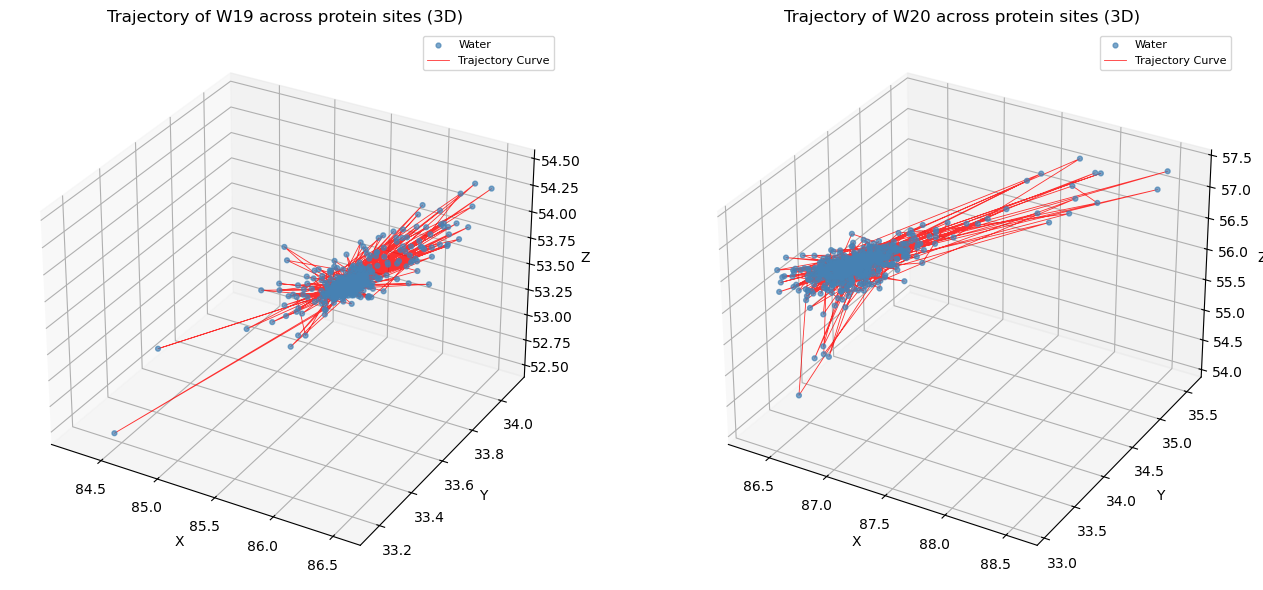

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def coords_from_pdb(pdb_path, atom_name=None):
    """Grab every atom's coordinates from a PDB, in file order."""
    coords = []
    with open(pdb_path) as f:
        for line in f:
            if line.startswith(('ATOM', 'HETATM')):
                name = line[12:16].strip()
                if atom_name is None or name == atom_name:
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    coords.append((x, y, z))
    return np.array(coords)


def plot_water_trajectory(coords, water_label, ax):
    x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]
    ax.scatter(x, y, z, c='steelblue', s=12, alpha=0.7, label='Water')
    ax.plot(x, y, z, c='red', linewidth=0.6, alpha=0.8, label='Trajectory Curve')
    ax.set_title(f'Trajectory of {water_label} across protein sites (3D)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend(loc='upper right', fontsize=8)


coords_W19 = coords_from_pdb('water_pdbs/O4/W19.pdb')
coords_W20 = coords_from_pdb('water_pdbs/O4/W20.pdb')

print('W19:', coords_W19.shape)   # should be (n_frames, 3)
print('W20:', coords_W20.shape)

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
plot_water_trajectory(coords_W19, 'W19', ax1)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
plot_water_trajectory(coords_W20, 'W20', ax2)
plt.tight_layout()
plt.savefig('/Users/yyklab/Downloads/W19_W20_trajectories.png', dpi=150)
plt.show()

## Walk Animation

W19: (711, 3)
W20: (648, 3)
saved W19_W20_walk.gif


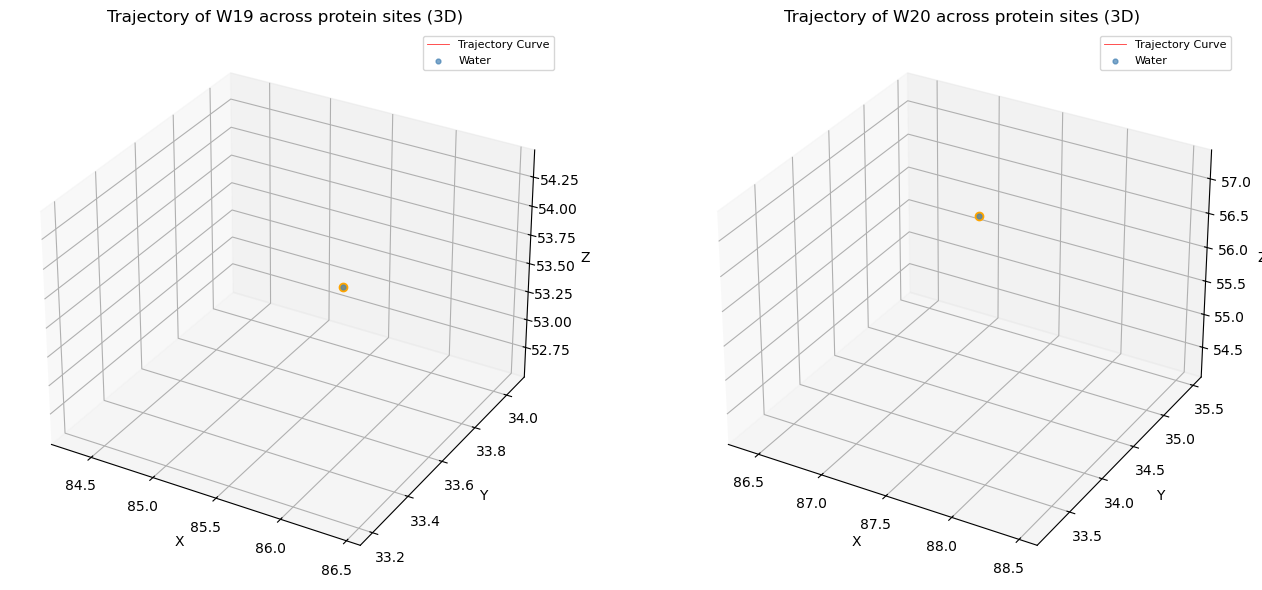

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

def coords_from_pdb(pdb_path, atom_name=None):
    """Grab every atom's coordinates from a PDB, in file order."""
    coords = []
    with open(pdb_path) as f:
        for line in f:
            if line.startswith(('ATOM', 'HETATM')):
                name = line[12:16].strip()
                if atom_name is None or name == atom_name:
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    coords.append((x, y, z))
    return np.array(coords)


coords_W19 = coords_from_pdb('water_pdbs/O4/W19.pdb')
coords_W20 = coords_from_pdb('water_pdbs/O4/W20.pdb')

print('W19:', coords_W19.shape)
print('W20:', coords_W20.shape)


def setup_axis(ax, coords, water_label):
    """Fix the axis limits/labels up front so they don't jump around as the trail grows."""
    ax.set_xlim(coords[:, 0].min(), coords[:, 0].max())
    ax.set_ylim(coords[:, 1].min(), coords[:, 1].max())
    ax.set_zlim(coords[:, 2].min(), coords[:, 2].max())
    ax.set_title(f'Trajectory of {water_label} across protein sites (3D)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')


fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
setup_axis(ax1, coords_W19, 'W19')
setup_axis(ax2, coords_W20, 'W20')

# artists we'll update each frame: the growing red line, all-visited dots, and the current position
line1, = ax1.plot([], [], [], c='red', linewidth=0.6, alpha=0.8, label='Trajectory Curve')
dots1 = ax1.scatter([], [], [], c='steelblue', s=12, alpha=0.7, label='Water')
head1, = ax1.plot([], [], [], 'o', c='orange', markersize=6)

line2, = ax2.plot([], [], [], c='red', linewidth=0.6, alpha=0.8, label='Trajectory Curve')
dots2 = ax2.scatter([], [], [], c='steelblue', s=12, alpha=0.7, label='Water')
head2, = ax2.plot([], [], [], 'o', c='orange', markersize=6)

ax1.legend(loc='upper right', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# animate up to the length of the longer trajectory
n_frames = max(len(coords_W19), len(coords_W20))

def update(i):
    for coords, line, dots, head in [
        (coords_W19, line1, dots1, head1),
        (coords_W20, line2, dots2, head2),
    ]:
        k = min(i + 1, len(coords))   # clamp for the shorter trajectory
        sub = coords[:k]
        line.set_data(sub[:, 0], sub[:, 1])
        line.set_3d_properties(sub[:, 2])
        dots._offsets3d = (sub[:, 0], sub[:, 1], sub[:, 2])
        head.set_data([sub[-1, 0]], [sub[-1, 1]])
        head.set_3d_properties([sub[-1, 2]])
    return line1, dots1, head1, line2, dots2, head2

anim = FuncAnimation(fig, update, frames=n_frames, interval=50, blit=False)

plt.tight_layout()
anim.save('/Users/yyklab/Downloads/W19_W20_walk.gif', writer=PillowWriter(fps=20))
print('saved W19_W20_walk.gif')

### Entry/Exit 


In [ ]:
import math
import matplotlib.pyplot as plt
from collections import defaultdict

# --- Configuration ---
REFERENCE_PDB = "0F.pdb_fittedto55all.pdb"
CONTACTS_FILE = "contacts_margaret_50_to_100.txt"

TARGETS = {
    "O1": [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 76, 77, 101, 102, 103, 104, 105, 106, 107, 108],
    "Cl": [59, 60, 66, 67, 68, 69, 70, 21, 22, 23, 24, 25, 61, 62, 40, 41, 42, 150, 117, 119, 121, 122, 150],
    "O4": [19, 20, 48, 49, 50, 51, 52, 53, 71, 72, 73]
}

def calc_distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2 + (p1[2]-p2[2])**2)

# --- 1. Load Reference Waters ---
print(f"Reading reference PDB: {REFERENCE_PDB}...")
ref_waters = {}
with open(REFERENCE_PDB, 'r') as f:
    for line in f:
        if line.startswith("HETATM") or line.startswith("ATOM"):
            chain = line[21].strip()
            res_name = line[17:20].strip()
            if chain == 'G' and res_name == 'OOO':
                try:
                    resSeq = int(line[22:26].strip())
                    x = float(line[30:38].strip())
                    y = float(line[38:46].strip())
                    z = float(line[46:54].strip())
                    
                    for channel, res_list in TARGETS.items():
                        if resSeq in res_list:
                            ref_waters[resSeq] = {'coords': (x, y, z), 'channel': channel}
                            break
                except ValueError:
                    pass

def get_closest_ref_water(coords):
    """Finds the closest 0F reference water to a given set of coordinates."""
    best_resSeq = None
    min_dist = float('inf')
    best_channel = None
    for resSeq, data in ref_waters.items():
        dist = calc_distance(coords, data['coords'])
        if dist < min_dist:
            min_dist = dist
            best_resSeq = resSeq
            best_channel = data['channel']
    return best_resSeq, best_channel

# --- 2. Extract First (Entry) and Last (Exit) Occurrences ---
# Dictionary to store the min t1 coordinates and max t2 coordinates for each MD water
md_bounds = defaultdict(lambda: {
    'min_t1': float('inf'), 'entry_coords': None,
    'max_t2': float('-inf'), 'exit_coords': None
})

print(f"Parsing {CONTACTS_FILE} for entry and exit coordinates...")
with open(CONTACTS_FILE, 'r') as f:
    for line in f:
        # Skip headers if present
        if not line[0].isdigit():
            continue
            
        parts = line.strip().split()
        if len(parts) >= 6:
            w_idx = parts[0]
            x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
            t1, t2 = int(parts[4]), int(parts[5])
            
            # Update Entry (lowest t1)
            if t1 < md_bounds[w_idx]['min_t1']:
                md_bounds[w_idx]['min_t1'] = t1
                md_bounds[w_idx]['entry_coords'] = (x, y, z)
                
            # Update Exit (highest t2)
            if t2 > md_bounds[w_idx]['max_t2']:
                md_bounds[w_idx]['max_t2'] = t2
                md_bounds[w_idx]['exit_coords'] = (x, y, z)

# --- 3. Match Coordinates to Reference Waters ---
print("Matching spatial coordinates to closest 0F reference waters...")
plot_data = {channel: {'entry_res': [], 'exit_res': []} for channel in TARGETS.keys()}

for w_idx, bounds in md_bounds.items():
    if bounds['entry_coords'] is None or bounds['exit_coords'] is None:
        continue
        
    entry_resSeq, entry_chan = get_closest_ref_water(bounds['entry_coords'])
    exit_resSeq, exit_chan = get_closest_ref_water(bounds['exit_coords'])
    
    # Group the water by the channel it entered through
    if entry_chan:
        plot_data[entry_chan]['entry_res'].append(entry_resSeq)
        plot_data[entry_chan]['exit_res'].append(exit_resSeq)

# --- 4. Generate Scatter Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Entry vs Exit Reference Waters (0F resSeq) by Channel", fontsize=16, y=1.05)

colors = {'O1': 'royalblue', 'Cl': 'mediumseagreen', 'O4': 'crimson'}

for ax, (channel, data) in zip(axes, plot_data.items()):
    ax.scatter(data['entry_res'], data['exit_res'], 
               c=colors[channel], alpha=0.6, edgecolors='k', s=60)
    
    # Formatting
    ax.set_title(f"{channel} Channel", fontsize=14)
    ax.set_xlabel("Entry Water (0F resSeq)", fontsize=12)
    ax.set_ylabel("Exit Water (0F resSeq)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Add a y=x diagonal line 
    # Points on this line mean the water entered and exited at the exact same reference site
    all_res = data['entry_res'] + data['exit_res']
    if all_res:
        min_val, max_val = min(all_res), max(all_res)
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.4, label='y=x (Same Site)')
        ax.legend()

plt.tight_layout()
plt.show()

Reading reference PDB: 0F.pdb_fittedto55all.pdb...
Parsing contacts_margaret_50_to_100.txt for entry and exit coordinates...
Matching spatial coordinates to closest 0F reference waters...


## RMSD of Channels

O4 waters to analyze: {'W19': 434869, 'W20': 692380, 'W48': 434956, 'W49': 434956, 'W50': 434965, 'W51': 836043, 'W52': 434965, 'W53': 687421, 'W71': 692374, 'W72': 435028, 'W73': 435028}
  W19 (idx 434869): RMSD = 0.210 Å, 220 episodes
  W20 (idx 692380): RMSD = 0.123 Å, 61 episodes
  W48 (idx 434956): RMSD = 0.042 Å, 16 episodes
  W49 (idx 434956): RMSD = 0.042 Å, 16 episodes
  W50 (idx 434965): RMSD = 1.553 Å, 74 episodes
  W51 (idx 836043): RMSD = 0.594 Å, 99 episodes
  W52 (idx 434965): RMSD = 1.553 Å, 74 episodes
  W53 (idx 687421): RMSD = 55.806 Å, 18 episodes
  W71 (idx 692374): RMSD = 0.510 Å, 35 episodes
  W72 (idx 435028): RMSD = 0.249 Å, 11 episodes
  W73 (idx 435028): RMSD = 0.249 Å, 11 episodes

Average RMSD for O4 waters: 5.54 Å
Lowest-RMSD (most confined) water:  W48  (0.04 Å)
Highest-RMSD (most mobile) water:   W53 (55.81 Å)


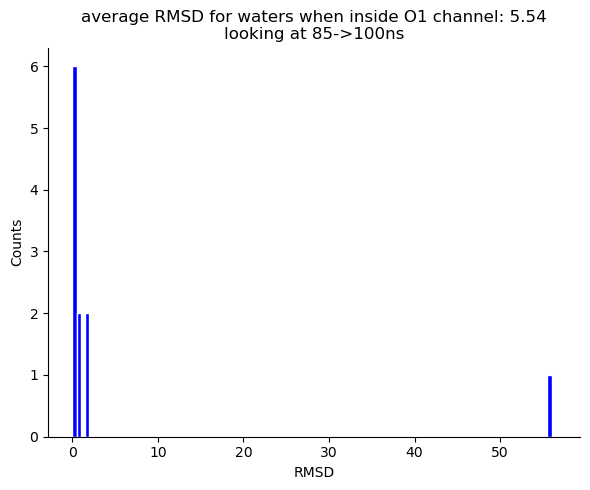


Saved: RMSD_hist_O1.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
#  RMSD-of-waters histogram for the O4 channel
#  (panel (a) of the reference figure)
# ============================================================

contacts_file = "contacts_margaret_50_to_100.txt"
channel       = "O1"
dt            = 2.0          # ps per frame
gap_tol       = 1

# --- W# -> water_index map (from your Frame-85 conversion table) ---
w_to_index = {
    "W1":434848, "W2":434851, "W3":434854, "W4":434857, "W5":434860, "W6":434863,
    "W7":434866, "W19":434869, "W20":692380, "W21":823294, "W22":434884, "W23":434887,
    "W24":434995, "W25":434887, "W26":434890, "W27":434890, "W28":434905, "W29":434899,
    "W30":434893, "W31":434902, "W32":696208, "W33":415318, "W34":530002, "W35":698548,
    "W36":698530, "W37":698542, "W38":510136, "W39":434908, "W40":434938, "W41":692365,
    "W42":434938, "W43":698554, "W44":472600, "W45":472600, "W46":434950, "W47":434953,
    "W48":434956, "W49":434956, "W50":434965, "W51":836043, "W52":434965, "W53":687421,
    "W54":434974, "W55":412978, "W56":412978, "W57":634171, "W58":698533, "W59":434992,
    "W60":473095, "W61":692362, "W62":434998, "W63":435001, "W64":435001, "W65":435007,
    "W66":435010, "W67":435019, "W68":412726, "W69":435013, "W70":412201, "W71":692374,
    "W72":435028, "W73":435028, "W74":435034, "W75":412675, "W76":435043, "W77":510136,
    "W79":480043, "W101":411463, "W102":775153, "W103":698539, "W104":698539, "W106":698527,
    "W107":780910, "W109":443104, "W111":545539, "W112":545539, "W113":819802, "W114":692371,
    "W115":545539, "W117":413008, "W118":412552, "W119":413008, "W121":471544, "W122":540367,
    "W125":438292, "W126":751981, "W127":618904, "W129":770215, "W130":412201, "W131":816754,
    "W132":414754, "W133":411649, "W134":628417, "W135":628417, "W136":670000, "W137":628399,
    "W140":668056, "W142":633484, "W143":768805, "W144":438292

}

# --- which W#'s are in the O4 channel ---
O4_wnums = [19, 20, 48, 49, 50, 51, 52, 53, 71, 72, 73]
o4_waters = {}   # W# -> water_index
for n in O4_wnums:
    key = f"W{n}"
    if key in w_to_index:
        o4_waters[key] = w_to_index[key]
    else:
        print(f"  (no index for {key}; skipping)")
print(f"O4 waters to analyze: {o4_waters}")

# ============================================================
# 1. Load ALL contact rows once, grouped by water_index
# ============================================================
from collections import defaultdict
by_water = defaultdict(list)   # water_index -> list of (t1, t2, tmid, x, y, z)
with open(contacts_file) as f:
    f.readline()
    for line in f:
        p = line.split()
        if len(p) < 6:
            continue
        try:
            widx = int(p[0])
        except ValueError:
            continue
        try:
            x, y, z = float(p[1]), float(p[2]), float(p[3])
            t1, t2  = int(p[4]), int(p[5])
        except ValueError:
            continue
        by_water[widx].append((t1, t2, 0.5*(t1+t2), x, y, z))

# ============================================================
# 2. Per-water RMSD (RMS deviation from its own mean position
#    while inside the channel), computed per contiguous run
#    then combined
# ============================================================
def water_rmsd(records):
    """RMS deviation of positions from the water's channel-resident
    centroid. Uses all in-channel episodes."""
    records = sorted(records, key=lambda r: r[2])
    pos = np.array([[r[3], r[4], r[5]] for r in records])
    if len(pos) < 2:
        return None
    c = pos.mean(axis=0)
    return np.sqrt(np.mean(np.sum((pos - c) ** 2, axis=1)))

rmsd_values = []
labels      = []
for wname, widx in o4_waters.items():
    recs = by_water.get(widx, [])
    r = water_rmsd(recs)
    if r is None:
        print(f"  {wname} (idx {widx}): <2 episodes, skipped")
        continue
    rmsd_values.append(r)
    labels.append(wname)
    print(f"  {wname} (idx {widx}): RMSD = {r:.3f} Å, {len(recs)} episodes")

rmsd_values = np.array(rmsd_values)
avg_rmsd = rmsd_values.mean()
print(f"\nAverage RMSD for O4 waters: {avg_rmsd:.2f} Å")

# --- identify most-common starting positions (low- vs high-RMSD groups) ---
# lowest-RMSD water (like W53 in your figure) and a high-RMSD one (W49)
order = np.argsort(rmsd_values)
low_water  = labels[order[0]]
high_water = labels[order[-1]]
print(f"Lowest-RMSD (most confined) water:  {low_water}  "
      f"({rmsd_values[order[0]]:.2f} Å)")
print(f"Highest-RMSD (most mobile) water:   {high_water} "
      f"({rmsd_values[order[-1]]:.2f} Å)")

# ============================================================
# 3. Histogram (panel a)
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.arange(0, np.ceil(rmsd_values.max()) + 1, 0.5)
ax.hist(rmsd_values, bins=bins, color="blue", edgecolor="white")
ax.set_xlabel("RMSD")
ax.set_ylabel("Counts")
ax.set_title(f"average RMSD for waters when inside {channel} channel: "
             f"{avg_rmsd:.2f}\nlooking at 85->100ns")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"/Users/yyklab/Downloads/RMSD_hist_{channel}.png", dpi=150)
plt.show()
print(f"\nSaved: RMSD_hist_{channel}.png")

Average time spent: 113.77 ns
Shortest stay: W53 (24.80 ns)
Longest stay:  W51 (139.08 ns)


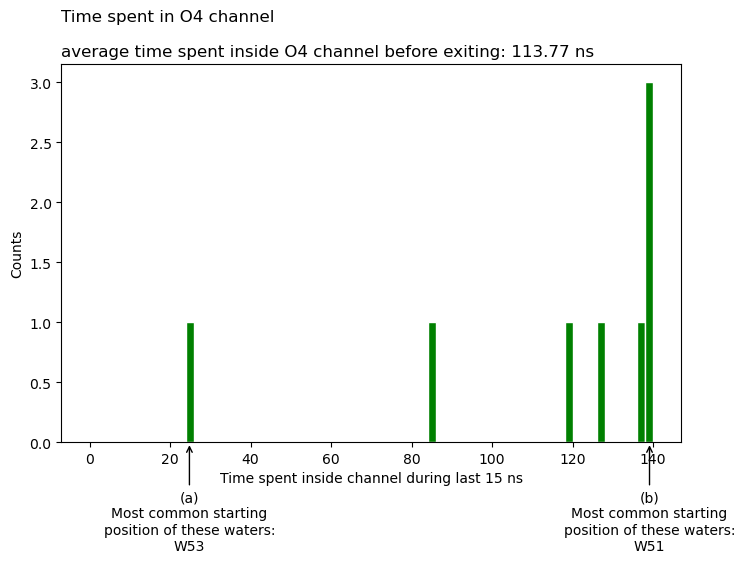

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
# Parameters & Mapping
# ============================================================
contacts_file = "contacts_margaret_50_to_100.txt" # Update to your actual file
dt_ns         = 0.02           # Nanoseconds per frame (adjust if your dt is different)

# --- Full W# -> water_index map ---
w_to_index = {
    "W1":434848, "W2":434851, "W3":434854, "W4":434857, "W5":434860, "W6":434863,
    "W7":434866, "W19":434869, "W20":692380, "W21":823294, "W22":434884, "W23":434887,
    "W24":434995, "W25":434887, "W26":434890, "W27":434890, "W28":434905, "W29":434899,
    "W30":434893, "W31":434902, "W32":696208, "W33":415318, "W34":530002, "W35":698548,
    "W36":698530, "W37":698542, "W38":510136, "W39":434908, "W40":434938, "W41":692365,
    "W42":434938, "W43":698554, "W44":472600, "W45":472600, "W46":434950, "W47":434953,
    "W48":434956, "W49":434956, "W50":434965, "W51":836043, "W52":434965, "W53":687421,
    "W54":434974, "W55":412978, "W56":412978, "W57":634171, "W58":698533, "W59":434992,
    "W60":473095, "W61":692362, "W62":434998, "W63":435001, "W64":435001, "W65":435007,
    "W66":435010, "W67":435019, "W68":412726, "W69":435013, "W70":412201, "W71":692374,
    "W72":435028, "W73":435028, "W74":435034, "W75":412675, "W76":435043, "W77":510136,
    "W79":480043, "W101":411463, "W102":775153, "W103":698539, "W104":698539, "W106":698527,
    "W107":780910, "W109":443104, "W111":545539, "W112":545539, "W113":819802, "W114":692371,
    "W115":545539, "W117":413008, "W118":412552, "W119":413008, "W121":471544, "W122":540367,
    "W125":438292, "W126":751981, "W127":618904, "W129":770215, "W130":412201, "W131":816754,
    "W132":414754, "W133":411649, "W134":628417, "W135":628417, "W136":670000, "W137":628399,
    "W140":668056, "W142":633484, "W143":768805, "W144":438292
}

# Reverse mapping to easily look up W# from the index later
index_to_w = {v: k for k, v in w_to_index.items()}

# --- which W#'s are in the O4 channel ---
O4_wnums = [19, 20, 48, 49, 50, 51, 52, 53, 71, 72, 73]
o4_waters = set()   
for n in O4_wnums:
    key = f"W{n}"
    if key in w_to_index:
        o4_waters.add(w_to_index[key])

# ============================================================
# 2. Parse Data & Calculate Time Spent
# ============================================================
time_spent_frames = defaultdict(int)

with open(contacts_file, 'r') as f:
    header = f.readline() 
    for line in f:
        p = line.split()
        if len(p) < 6:
            continue
        try:
            widx = int(p[0])
            t1   = int(p[4])
            t2   = int(p[5])
        except ValueError:
            continue
            
        # Filter for O4 channel waters
        if widx not in o4_waters: 
            continue
        
        # Calculate duration of this episode and add to total
        duration = t2 - t1
        time_spent_frames[widx] += duration

# Convert to nanoseconds and pair with labels
residence_times = []
labels = []

for widx, frames in time_spent_frames.items():
    time_ns = frames * dt_ns
    residence_times.append(time_ns)
    
    w_name = index_to_w.get(widx, f"ID:{widx}")
    labels.append(w_name)

residence_times = np.array(residence_times)
labels = np.array(labels)

# ============================================================
# 3. Identify Extremes (for Annotations)
# ============================================================
if len(residence_times) == 0:
    print("No O4 waters found in the contacts file. Check your file and mapping.")
    exit()

avg_time = residence_times.mean()

sort_idx = np.argsort(residence_times)
sorted_times = residence_times[sort_idx]
sorted_labels = labels[sort_idx]

shortest_stay_w = sorted_labels[0]
longest_stay_w = sorted_labels[-1]

print(f"Average time spent: {avg_time:.2f} ns")
print(f"Shortest stay: {shortest_stay_w} ({sorted_times[0]:.2f} ns)")
print(f"Longest stay:  {longest_stay_w} ({sorted_times[-1]:.2f} ns)")

# ============================================================
# 4. Generate Histogram (Panel a)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

# ---- AJDUST BIN SIZE HERE ----
bin_width_ns = 2.0  # Change this value to make bins wider (e.g., 5.0) or narrower (e.g., 0.5)
# ------------------------------

bins = np.arange(0, np.ceil(residence_times.max()) + bin_width_ns, bin_width_ns) 
ax.hist(residence_times, bins=bins, color="green", edgecolor="white")

ax.set_xlabel("Time spent inside channel during last 15 ns")
ax.set_ylabel("Counts")
ax.set_title(f"Time spent in O4 channel\n\naverage time spent inside O4 channel before exiting: {avg_time:.2f} ns", loc='left')

# Add Annotations for shortest and longest stays
ax.annotate(f"(a)\nMost common starting\nposition of these waters:\n{shortest_stay_w}",
            xy=(sorted_times[0], 0), xycoords='data',
            xytext=(sorted_times[0], -0.4), textcoords='data',
            arrowprops=dict(facecolor='black', arrowstyle='->'),
            horizontalalignment='center', verticalalignment='top')

ax.annotate(f"(b)\nMost common starting\nposition of these waters:\n{longest_stay_w}",
            xy=(sorted_times[-1], 0), xycoords='data',
            xytext=(sorted_times[-1], -0.4), textcoords='data',
            arrowprops=dict(facecolor='black', arrowstyle='->'),
            horizontalalignment='center', verticalalignment='top')

# Formatting tweaks 
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
plt.subplots_adjust(bottom=0.25) 

plt.savefig("/Users/yyklab/Downloads/Time_spent_O4.png", dpi=150, bbox_inches="tight")
plt.show()